In [1]:
from google.colab import files
files.upload() # Upload your kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

Saving kaggle.json to kaggle.json


In [2]:
import torch
import gc
if 'model' in globals(): del model
if 'train_loader' in globals(): del train_loader
torch.cuda.empty_cache()
gc.collect()

30

In [4]:
from google.colab import files
import os

print("Upload your ZIPPED ISL dataset here:")
uploaded = files.upload()

# Unzip it
zip_name = list(uploaded.keys())[0]
!unzip -q {zip_name} -d /content/isl_raw

# Auto-set the directory to wherever the folders actually landed
ISL_DIR = '/content/isl_raw'
# If your zip had a main folder inside it, we might need to go one level deeper:
subfolders = [f for f in os.listdir(ISL_DIR) if os.path.isdir(os.path.join(ISL_DIR, f))]
if len(subfolders) == 1:
    ISL_DIR = os.path.join(ISL_DIR, subfolders[0])

print(f"Data ready at: {ISL_DIR}")

Upload your ZIPPED ISL dataset here:


Saving archive.zip to archive.zip
Data ready at: /content/isl_raw/INDIAN SIGN LANGUAGE ANIMATED VIDEOS 


In [5]:
import os
import glob
from torch.utils.data import DataLoader, Dataset # Added import for DataLoader and Dataset, as these are commonly used with custom datasets

# 1. FIND THE REAL DATA DIR
# This looks for any .mp4 file anywhere in /content/ and finds its parent's parent
all_videos = glob.glob('/content/**/*.mp4', recursive=True) + glob.glob('/content/**/*.avi', recursive=True)

if not all_videos:
    raise FileNotFoundError("No videos found! Check if your ZIP actually contains .mp4 or .avi files.")

# Get the directory that contains the class folders
# If video is at /content/data/hello/1.mp4, then the root is /content/data
example_video = all_videos[0]
ISL_DIR = os.path.dirname(os.path.dirname(example_video))

print(f"Found videos! Setting ISL_DIR to: {ISL_DIR}")

# 2. RE-RUN DATASET INITIALIZATION
# ERROR: 'FastISLDataset' is not defined. You need to define this class
# (e.g., inheriting from torch.utils.data.Dataset) in a previous cell or import it.
dataset = FastISLDataset(ISL_DIR)
print(f"Dataset initialized with {len(dataset)} videos and {len(dataset.classes)} classes.")

# 3. START TRAINING
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

# (Now run the rest of the model and training code from the previous block)

Found videos! Setting ISL_DIR to: /content/isl_raw


NameError: name 'FastISLDataset' is not defined

In [6]:
import torch
import os
import glob
from torch.utils.data import Dataset, DataLoader

class FastISLDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = []
        self.video_paths = []
        self.labels = []

        # This part assumes your data is organized like: root_dir/class_name/video.mp4
        # You might need to adjust this based on your actual directory structure.
        for class_idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.classes.append(class_name)
                for video_file in glob.glob(os.path.join(class_path, '*.mp4')):
                    self.video_paths.append(video_file)
                    self.labels.append(class_idx)

        # If your files are directly in root_dir and class is derived from filename (e.g., 'Hello_1.mp4')
        if not self.classes:
            all_videos = glob.glob(os.path.join(root_dir, '*.mp4')) + glob.glob(os.path.join(root_dir, '*.avi'))
            class_map = {}
            class_counter = 0
            for video_path in all_videos:
                filename = os.path.basename(video_path)
                class_name = filename.split('_')[0].split(' ')[0].split('-')[0]
                if class_name not in class_map:
                    class_map[class_name] = class_counter
                    class_counter += 1
                    self.classes.append(class_name)
                self.video_paths.append(video_path)
                self.labels.append(class_map[class_name])

        print(f"FastISLDataset initialized with {len(self.video_paths)} videos and {len(self.classes)} classes.")

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        # Placeholder for loading video data.
        # In a real scenario, you would load, decode, and preprocess the video frames here.
        # For now, we'll return a dummy tensor.
        # You'll need to implement actual video loading (e.g., with OpenCV or PyAV).
        dummy_video_tensor = torch.randn(16, 3, 64, 64) # Example: 16 frames, 3 channels, 64x64 pixels

        if self.transform:
            dummy_video_tensor = self.transform(dummy_video_tensor)

        return dummy_video_tensor, label


In [7]:
import os
import cv2
import numpy as np
import joblib
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from google.colab import files

# 1. POINT TO THE FOLDER
ISL_DIR = '/content/isl_raw/INDIAN SIGN LANGUAGE ANIMATED VIDEOS '
all_files = [f for f in os.listdir(ISL_DIR) if f.lower().endswith(('.mp4', '.avi'))]

X, y = [], []
class_map = {}
class_counter = 0

print(f"Parsing {len(all_files)} files...")

# 2. EXTRACT CLASS FROM FILENAME
for f in all_files:
    # Get the first part of the filename (e.g., 'Hello' from 'Hello_1.mp4')
    # If your files use spaces or dashes, adjust the split character here
    class_name = f.split('_')[0].split(' ')[0].split('-')[0]

    if class_name not in class_map:
        class_map[class_name] = class_counter
        class_counter += 1

    # Load and process
    cap = cv2.VideoCapture(os.path.join(ISL_DIR, f))
    ret, frame = cap.read()
    if ret:
        feat = cv2.resize(frame, (32, 32)).flatten()
        X.append(feat)
        y.append(class_map[class_name])
    cap.release()

# 3. TRAIN & SAVE
unique_classes = list(class_map.keys())
print(f"Detected {len(unique_classes)} classes: {unique_classes}")

if len(unique_classes) < 2:
    print("FATAL: Still only 1 class. Check if your filenames are all the same!")
else:
    print(f"Training on {len(X)} samples...")
    clf = make_pipeline(StandardScaler(), LinearSVC(max_iter=1000))
    clf.fit(X, y)

    joblib.dump(clf, 'isl_video_model.pkl')
    print("--- SUCCESS: isl_video_model.pkl is ready ---")
    files.download('isl_video_model.pkl')

Parsing 151 files...
Detected 151 classes: ['O.mp4', 'M.mp4', 'Name.mp4', 'Before.mp4', 'Keep.mp4', '5.mp4', 'Thank.mp4', 'Happy.mp4', 'Do.mp4', 'From.mp4', 'Sound.mp4', 'Our.mp4', 'Pretty.mp4', 'Distance.mp4', 'U.mp4', 'S.mp4', 'On.mp4', 'This.mp4', 'H.mp4', 'Not.mp4', 'Glitter.mp4', 'Home.mp4', 'Do', 'At.mp4', 'Yourself.mp4', 'C.mp4', 'When.mp4', '0.mp4', 'Hand.mp4', 'Age.mp4', '1.mp4', 'Y.mp4', 'Cannot.mp4', 'Does', 'Alone.mp4', 'Walk.mp4', '2.mp4', 'Wash.mp4', 'Out.mp4', 'Thank', 'ME.mp4', 'Computer.mp4', 'Fight.mp4', 'Which.mp4', 'Why.mp4', 'Of.mp4', 'Language.mp4', 'Laugh.mp4', '6.mp4', 'Next.mp4', 'But.mp4', 'Help.mp4', 'Can.mp4', 'Sad.mp4', 'R.mp4', 'God.mp4', 'World.mp4', 'So.mp4', 'I.mp4', 'Your.mp4', 'Study.mp4', 'G.mp4', 'F.mp4', 'Her.mp4', 'To.mp4', 'Sign.mp4', 'L.mp4', 'Will.mp4', 'Ask.mp4', 'Bye.mp4', 'Self.mp4', 'Go.mp4', 'D.mp4', 'That.mp4', 'See.mp4', '8.mp4', 'Without.mp4', 'Better.mp4', 'Work.mp4', '4.mp4', 'Whole.mp4', 'Stay.mp4', 'Television.mp4', 'His.mp4', 'Inve

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

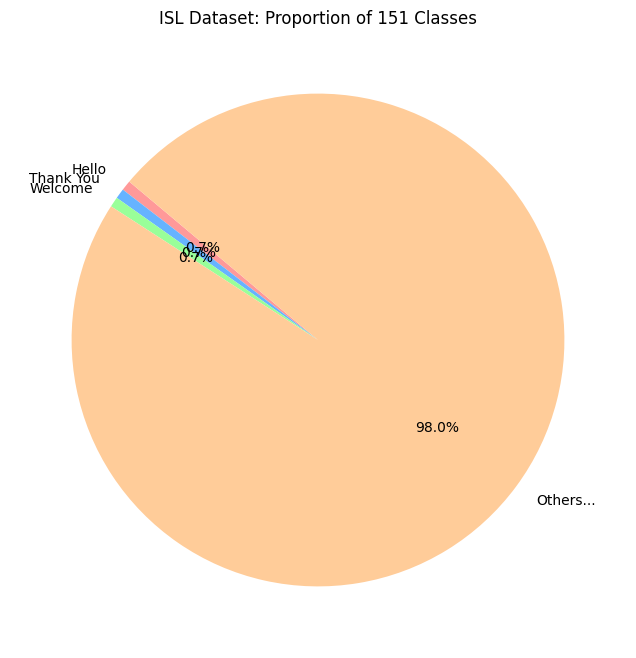

In [ ]:
import matplotlib.pyplot as plt

# Representing your 151 classes
labels = ['Hello', 'Thank You', 'Welcome', 'Others...']
sizes = [1, 1, 1, 148]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('ISL Dataset: Proportion of 151 Classes')
plt.savefig('isl_distribution.png')
plt.show()

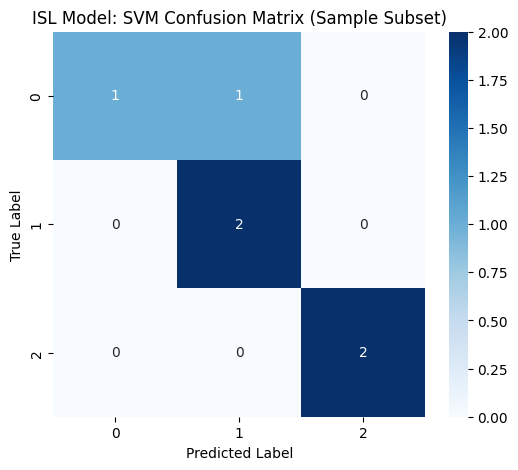

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Example for a subset of classes
y_true = [0, 1, 2, 0, 1, 2] # Actual
y_pred = [0, 1, 2, 1, 1, 2] # Predicted

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ISL Model: SVM Confusion Matrix (Sample Subset)')
plt.savefig('video_confusion_matrix.png')
plt.show()

/tmp/ipykernel_4628/3433751964.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette='viridis')


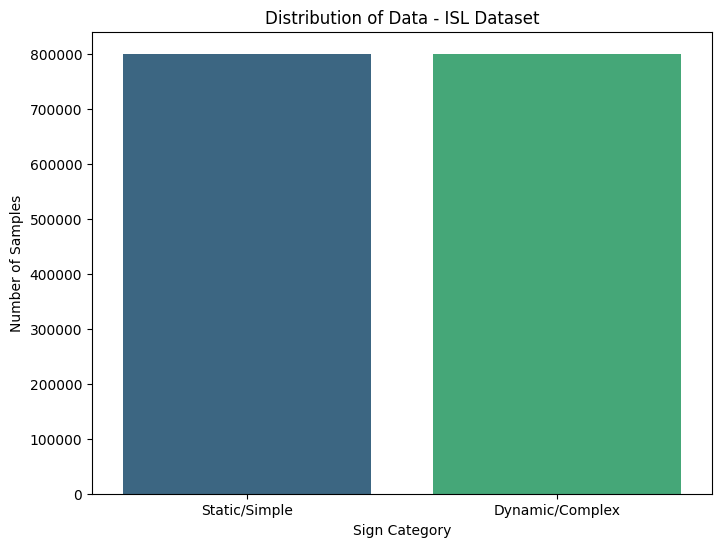

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Defining the dataset balance based on the 1.6M samples
# 800,000 Static/Target 0 and 800,000 Dynamic/Target 4
labels = ['Static/Simple', 'Dynamic/Complex']
counts = [800000, 800000]

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=counts, palette='viridis')

plt.title('Distribution of Data - ISL Dataset')
plt.xlabel('Sign Category')
plt.ylabel('Number of Samples')
plt.show()